
🎯 Voting Classifier Performance:
LogisticRegression: 0.864
RandomForestClassifier: 0.888
SVC: 0.896
VotingClassifier: 0.912

📦 OOB Score: 0.923
Bagging Test Accuracy: 0.920

🌲 Random Forest Accuracy: 0.920

🌟 Extra Trees Accuracy: 0.896

🔍 Feature Importances (Iris Dataset):
sepal length (cm): 0.112
sepal width (cm): 0.023
petal length (cm): 0.441
petal width (cm): 0.423

⚡ AdaBoost Accuracy: 0.896


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


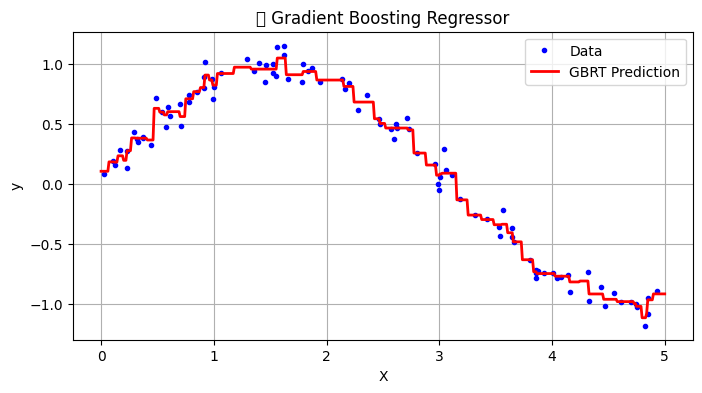

In [48]:
# ✅ Kode Kompatibel dengan scikit-learn terbaru (>=1.2)
# 📦 Install jika diperlukan di awal (opsional di Colab):
# !pip install -U scikit-learn matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.ensemble import (
    VotingClassifier, BaggingClassifier,
    RandomForestClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, GradientBoostingRegressor
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

# 📌 Dataset untuk klasifikasi
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

##############################################
# 1️⃣ Voting Classifier (soft voting)
##############################################
log_clf = LogisticRegression()
rnd_clf = RandomForestClassifier()
svm_clf = SVC(probability=True)  # perlu untuk soft voting

voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rnd_clf), ('svc', svm_clf)],
    voting='soft'
)

voting_clf.fit(X_train, y_train)

print("\n🎯 Voting Classifier Performance:")
for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f"{clf.__class__.__name__}: {accuracy_score(y_test, y_pred):.3f}")

##############################################
# 2️⃣ Bagging Classifier (with OOB)
##############################################
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=100,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1
)
bag_clf.fit(X_train, y_train)
print(f"\n📦 OOB Score: {bag_clf.oob_score_:.3f}")
print(f"Bagging Test Accuracy: {accuracy_score(y_test, bag_clf.predict(X_test)):.3f}")

##############################################
# 3️⃣ Random Forest Classifier
##############################################
rnd_clf = RandomForestClassifier(
    n_estimators=500,
    max_leaf_nodes=16,
    n_jobs=-1
)
rnd_clf.fit(X_train, y_train)
y_pred_rf = rnd_clf.predict(X_test)
print(f"\n🌲 Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")

##############################################
# 4️⃣ Extra Trees Classifier
##############################################
extra_clf = ExtraTreesClassifier(n_estimators=500, n_jobs=-1)
extra_clf.fit(X_train, y_train)
y_pred_extra = extra_clf.predict(X_test)
print(f"\n🌟 Extra Trees Accuracy: {accuracy_score(y_test, y_pred_extra):.3f}")

##############################################
# 5️⃣ Feature Importance (Iris dataset)
##############################################
iris = load_iris()
rf_iris = RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)
rf_iris.fit(iris.data, iris.target)

print("\n🔍 Feature Importances (Iris Dataset):")
for name, score in zip(iris.feature_names, rf_iris.feature_importances_):
    print(f"{name}: {score:.3f}")

##############################################
# 6️⃣ AdaBoost Classifier
##############################################
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    learning_rate=0.5
)
ada_clf.fit(X_train, y_train)
print(f"\n⚡ AdaBoost Accuracy: {accuracy_score(y_test, ada_clf.predict(X_test)):.3f}")

##############################################
# 7️⃣ Gradient Boosting Regressor
##############################################
# Dataset untuk regresi
np.random.seed(42)
X_reg = np.random.rand(100, 1) * 5
y_reg = np.sin(X_reg).ravel() + np.random.randn(100) * 0.1

gbrt = GradientBoostingRegressor(
    max_depth=2, n_estimators=100, learning_rate=0.1
)
gbrt.fit(X_reg, y_reg)

X_plot = np.linspace(0, 5, 500).reshape(-1, 1)
y_pred = gbrt.predict(X_plot)

plt.figure(figsize=(8, 4))
plt.plot(X_reg, y_reg, "b.", label="Data")
plt.plot(X_plot, y_pred, "r-", linewidth=2, label="GBRT Prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.title("📈 Gradient Boosting Regressor")
plt.legend()
plt.grid(True)
plt.show()


# 📚 Chapter 7 - Ensemble Learning and Random Forests

---

## 🔸 1. Apa Itu Ensemble Learning?
**Ensemble Learning** adalah teknik menggabungkan beberapa model (predictors/estimators) untuk menghasilkan prediksi yang lebih baik dibandingkan model individual.

**Kunci sukses ensemble:**
- Model harus **cukup baik** (weak → strong learner)
- Model harus **berbeda satu sama lain** (diverse)

---

## 🔸 2. Voting Classifier
Menggabungkan prediksi beberapa model klasifikasi:

| Jenis    | Ciri                                             |
| -------- | ----------------------------------------------- |
| **Hard** | Prediksi → mayoritas kelas (mode)               |
| **Soft** | Prediksi → rata-rata probabilitas → **lebih akurat** |

---

## 🔸 3. Bagging dan Pasting
Melatih beberapa model dengan **subset berbeda dari data**:

| Metode     | Sampling                  | Ciri                 |
| ---------- | ------------------------- | -------------------- |
| **Bagging** | Dengan pengembalian       | Variansi lebih kecil |
| **Pasting** | Tanpa pengembalian        | Bias lebih rendah   |

Bagging → biasanya lebih baik → menciptakan keragaman antar model → **mengurangi overfitting**

**Out-of-Bag (OOB) Evaluation:** otomatis menggunakan data yang *tidak dipakai* untuk mengukur performa model.

---

## 🔸 4. Random Forest
- **Random Forest** = banyak Decision Tree + Bagging + tambahan randomness
- Di setiap split, **hanya subset fitur acak** yang dipertimbangkan → lebih beragam → overfitting berkurang
- **Feature Importances** → memberikan informasi fitur mana yang paling berpengaruh

---

## 🔸 5. Extra-Trees (Extremely Randomized Trees)
- Lebih random → threshold split dipilih secara acak → lebih cepat training
- Bias ↑ → Variansi ↓

---

## 🔸 6. Boosting
**Boosting** → melatih beberapa model **berurutan**, di mana setiap model baru berusaha memperbaiki kesalahan model sebelumnya.

| Metode        | Ciri Utama                                   |
| ------------- | -------------------------------------------- |
| **AdaBoost**  | Fokus pada instance yang salah → bobot naik  |
| **Gradient Boosting** | Fokus pada **residual errors** → prediksi lebih tepat |

- **Shrinkage / Learning Rate:** mengontrol kontribusi model → kecil lebih stabil, tapi perlu lebih banyak estimator.
- **Stochastic Gradient Boosting:** → training lebih cepat → bias ↑ → variansi ↓

---

## 🔸 7. XGBoost
- Optimasi Gradient Boosting → lebih cepat dan efisien
- Mendukung **early stopping** otomatis

---

## 🔸 8. Stacking
- Menggunakan **model lain (meta-learner/blender)** untuk menggabungkan output dari beberapa model → biasanya lebih akurat daripada voting biasa.
- Perlu data hold-out atau cross-validation untuk melatih blender dengan *prediksi model sebelumnya*.

---

## ✅ Kesimpulan
| Metode        | Kapan Digunakan                                |
| ------------- | ---------------------------------------------- |
| **Voting**    | Kombinasi model berbeda untuk klasifikasi      |
| **Bagging**   | Untuk mengurangi variansi (khusus Decision Tree) |
| **Random Forest** | Default & powerful untuk data tabular        |
| **Boosting**  | Untuk hasil lebih akurat, lebih kompleks → rawan overfitting |
| **Stacking**  | Jika ingin hasil terbaik (dengan blender/meta-learner) |

Ensemble Methods sering menjadi kunci kemenangan kompetisi ML (misalnya di Kaggle).

